# Etapa 1 — Baselines registrados no MLflow

> **Tech Challenge — Telco Customer Churn Prediction**  
> Etapa 1: Entendimento e Preparação (Disciplinas 01 e 02)

**Entregável:** DummyClassifier e Logistic Regression treinados, com parâmetros, métricas e versão do dataset registrados no MLflow.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

def _find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = _find_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root : {ROOT}")

Project root : c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import mlflow
import pandas as pd

from src.config import DataConfig, MLflowConfig, setup_logging
from src.data.loader import ChurnDataLoader
from src.models.trainer import SklearnTrainer
from src.service.mlflow_service import MLflowService

setup_logging("INFO")
print(f"MLflow : {mlflow.__version__}")

MLflow : 3.12.0


## 2. Configuração

In [3]:
data_cfg    = DataConfig()
mlflow_cfg  = MLflowConfig(experiment_name="telco-churn-etapa1")

print(f"Dataset      : {data_cfg.path}")
print(f"Experimento  : {mlflow_cfg.experiment_name}")
print(f"Tracking URI : {mlflow_cfg.tracking_uri}")

Dataset      : c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1\src\data\churn.csv
Experimento  : telco-churn-etapa1
Tracking URI : sqlite:///mlruns.db


## 3. Carregamento e pré-processamento

In [4]:
loader = ChurnDataLoader(
    path=data_cfg.path,
    target=data_cfg.target,
    test_size=data_cfg.test_size,
    random_state=data_cfg.random_state,
)
df = loader.load()
X_train, X_test, y_train, y_test, _ = loader.get_splits(df)
dataset_info = loader.dataset_info()

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Dataset SHA-256 (prefix): {dataset_info['sha256']}")

2026-06-02T22:41:54 | INFO     | src.data.loader | Loading dataset from c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1\src\data\churn.csv
2026-06-02T22:41:54 | INFO     | src.data.loader | Raw shape: (7043, 21)
2026-06-02T22:41:54 | INFO     | src.data.loader | Dropped 11 rows with nulls
2026-06-02T22:41:54 | INFO     | src.data.loader | Clean shape: (7032, 20) | churn rate: 26.6%
2026-06-02T22:41:54 | INFO     | src.data.loader | Split → train=5625 test=1407 | features=30

Train: (5625, 30) | Test: (1407, 30)
Dataset SHA-256 (prefix): 88be4b93fbe0


## 4. Treinamento e registro dos baselines

| Modelo | Propósito |
|--------|----------|
| `DummyClassifier` | Piso mínimo: sempre prediz a classe majoritária |
| `LogisticRegression` | Baseline linear: referência para modelos mais complexos |

In [ ]:
from src.models.registry import MODEL_REGISTRY

mlflow_svc = MLflowService(
    tracking_uri=mlflow_cfg.tracking_uri,
    experiment_name=mlflow_cfg.experiment_name,
)
trainer = SklearnTrainer()

BASELINE_KEYS = ["dummy", "logistic_regression"]

results = {}

for key in BASELINE_KEYS:
    entry = MODEL_REGISTRY[key]
    run_name = entry["model"].__class__.__name__
    fitted, metrics = trainer.fit_evaluate(entry["model"], X_train, y_train, X_test, y_test)
    mlflow_svc.log_sklearn_run(
        run_name=run_name,
        model=fitted,
        metrics=metrics,
        params=entry["params"],
        dataset_info=dataset_info,
        tags={"stage": "etapa1", "model_family": "baseline"},
        register=True,
        **entry["mlflow"],
    )
    results[run_name] = metrics
    print(f"[{run_name}]")
    for k, v in metrics.items():
        print(f"  {k:12s}: {v}")

print("
✅ Baselines registrados no MLflow.")

## 5. Comparação e análise

,accuracy,f1_macro,precision,recall,roc_auc
DummyClassifier,0.7342,0.4234,0.0000,0.0000,0.5000
LogisticRegression,0.8053,0.7405,0.6515,0.5749,0.8361



Ganho da Logistic Regression sobre DummyClassifier:
  accuracy    : +0.0711
  f1_macro    : +0.3171
  roc_auc     : +0.3361


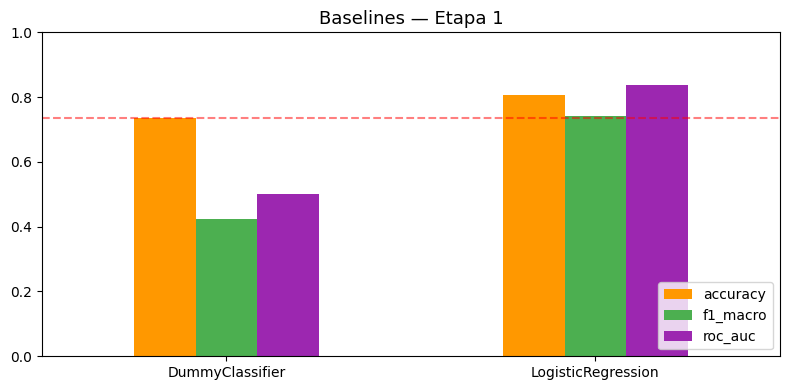


MLflow UI: mlflow ui --backend-store-uri sqlite:///mlruns.db --port 5000


In [6]:
import matplotlib.pyplot as plt

df_res = pd.DataFrame(results).T.apply(pd.to_numeric, errors="coerce")
display(df_res.style.format("{:.4f}").highlight_max(color="#d4edda"))

# Quanto a LR melhora sobre o Dummy?
dummy_m  = results["DummyClassifier"]
lr_m     = results["LogisticRegression"]

print(f"\nGanho da Logistic Regression sobre DummyClassifier:")
for k in ["accuracy", "f1_macro", "roc_auc"]:
    if k in lr_m and k in dummy_m and lr_m[k] and dummy_m[k]:
        delta = lr_m[k] - dummy_m[k]
        print(f"  {k:12s}: +{delta:.4f}")

# Visualização
fig, ax = plt.subplots(figsize=(8, 4))
metric_cols = [c for c in ["accuracy", "f1_macro", "roc_auc"] if c in df_res.columns]
df_plot = df_res[metric_cols]
df_plot.plot(kind="bar", ax=ax, color=["#FF9800", "#4CAF50", "#9C27B0"], width=0.5)
ax.set_title("Baselines — Etapa 1", fontsize=13)
ax.set_xticklabels(df_plot.index, rotation=0)
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.axhline(1 - df["Churn"].mean(), color="red", linestyle="--",
           alpha=0.5, label="Accuracy ingênua")
plt.tight_layout()

DOCS = ROOT / "src" / "docs"
DOCS.mkdir(exist_ok=True)
plt.savefig(DOCS / "etapa1_baselines.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nMLflow UI: mlflow ui --backend-store-uri {mlflow_cfg.tracking_uri} --port 5000")